In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv('../Data/fetal_health_classification.csv')

print(df.shape)
df.head()

(2126, 36)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V27,V28,V29,V30,V31,V32,V33,V34,V35,Class
0,23,240,357,120,120,0,0,0,73,0.5,...,0,0,0,0,0,0,0,1,0,9.0
1,45,5,632,132,132,4,0,4,17,2.1,...,0,0,0,0,1,0,0,0,0,6.0
2,45,177,779,133,133,2,0,5,16,2.1,...,0,0,0,0,1,0,0,0,0,6.0
3,45,411,1192,134,134,2,0,6,16,2.4,...,0,0,0,0,1,0,0,0,0,6.0
4,45,533,1147,132,132,4,0,5,16,2.4,...,1,0,0,0,0,0,0,0,0,2.0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 36 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      2126 non-null   int64  
 1   V2      2126 non-null   int64  
 2   V3      2126 non-null   int64  
 3   V4      2126 non-null   int64  
 4   V5      2126 non-null   int64  
 5   V6      2126 non-null   int64  
 6   V7      2126 non-null   int64  
 7   V8      2126 non-null   int64  
 8   V9      2126 non-null   int64  
 9   V10     2126 non-null   float64
 10  V11     2126 non-null   int64  
 11  V12     2126 non-null   float64
 12  V13     2126 non-null   int64  
 13  V14     2126 non-null   int64  
 14  V15     2126 non-null   int64  
 15  V16     2126 non-null   int64  
 16  V17     2126 non-null   int64  
 17  V18     2126 non-null   int64  
 18  V19     2126 non-null   int64  
 19  V20     2126 non-null   int64  
 20  V21     2126 non-null   int64  
 21  V22     2126 non-null   int64  
 22  

In [52]:
col_list = []
for column in df.columns:
    col_list.append(column)

In [53]:
print(col_list)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'Class']


In [54]:
df.corr()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V27,V28,V29,V30,V31,V32,V33,V34,V35,Class
V1,1.000000,-0.087695,-0.109810,-0.109168,-0.109168,0.095095,-0.131360,-0.097298,-0.182268,0.008597,...,-0.000560,-0.021483,0.060958,-0.029836,0.080377,-0.026446,-0.101669,0.033620,0.051984,0.034158
V2,-0.087695,1.000000,0.944912,-0.020400,-0.020400,-0.038359,-0.133849,0.225595,-0.126355,0.040505,...,-0.016470,0.021245,-0.071332,-0.027566,0.089531,0.069631,0.085915,-0.124923,-0.147421,-0.080512
V3,-0.109810,0.944912,1.000000,-0.013979,-0.013979,0.071572,-0.119249,0.386856,-0.066374,0.044605,...,0.018013,-0.038732,-0.082700,-0.015549,0.138695,0.043638,0.089144,-0.145832,-0.159555,-0.080251
V4,-0.109168,-0.020400,-0.013979,1.000000,1.000000,-0.077967,-0.033305,-0.127722,0.305570,-0.279607,...,-0.048750,-0.062894,0.005591,0.158350,-0.130368,-0.030849,-0.123625,0.072908,0.224699,0.143766
V5,-0.109168,-0.020400,-0.013979,1.000000,1.000000,-0.077967,-0.033305,-0.127722,0.305570,-0.279607,...,-0.048750,-0.062894,0.005591,0.158350,-0.130368,-0.030849,-0.123625,0.072908,0.224699,0.143766
V6,0.095095,-0.038359,0.071572,-0.077967,-0.077967,1.000000,0.053956,0.212100,-0.197985,0.191378,...,0.467663,-0.113805,0.328854,-0.116153,0.264657,-0.255090,-0.142017,-0.139010,-0.207385,-0.254838
V7,-0.131360,-0.133849,-0.119249,-0.033305,-0.033305,0.053956,1.000000,-0.036626,-0.116461,0.138061,...,-0.053710,-0.022823,0.058019,-0.024547,0.113454,0.001145,0.088352,-0.003270,-0.030545,0.077982
V8,-0.097298,0.225595,0.386856,-0.127722,-0.127722,0.212100,-0.036626,1.000000,-0.079651,0.232687,...,0.023350,-0.097485,-0.029741,-0.026050,0.243954,0.084710,0.110418,-0.203673,-0.224804,-0.072633
V9,-0.182268,-0.126355,-0.066374,0.305570,0.305570,-0.197985,-0.116461,-0.079651,1.000000,-0.430705,...,-0.139987,-0.142252,-0.113669,0.072269,-0.198840,-0.132195,0.141450,0.304762,0.330765,0.283486
V10,0.008597,0.040505,0.044605,-0.279607,-0.279607,0.191378,0.138061,0.232687,-0.430705,1.000000,...,-0.045688,0.021396,0.096120,-0.126216,0.284401,0.259776,0.271830,-0.209573,-0.286763,0.078012


In [55]:
display(df.head())
display(df.sample(5))
display(df.info())
display(df.describe())
display(df.isnull().sum())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V27,V28,V29,V30,V31,V32,V33,V34,V35,Class
0,23,240,357,120,120,0,0,0,73,0.5,...,0,0,0,0,0,0,0,1,0,9.0
1,45,5,632,132,132,4,0,4,17,2.1,...,0,0,0,0,1,0,0,0,0,6.0
2,45,177,779,133,133,2,0,5,16,2.1,...,0,0,0,0,1,0,0,0,0,6.0
3,45,411,1192,134,134,2,0,6,16,2.4,...,0,0,0,0,1,0,0,0,0,6.0
4,45,533,1147,132,132,4,0,5,16,2.4,...,1,0,0,0,0,0,0,0,0,2.0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V27,V28,V29,V30,V31,V32,V33,V34,V35,Class
1486,14,1338,2462,132,132,7,0,9,30,1.5,...,0,0,0,0,1,0,0,0,0,6.0
2023,10,0,552,129,129,0,1,3,58,4.3,...,0,0,0,0,0,1,0,0,0,7.0
2050,3,2,525,128,128,0,1,1,70,1.9,...,0,1,0,0,0,0,0,0,0,3.0
319,30,526,941,150,150,0,10,0,79,0.2,...,0,0,0,0,0,0,0,1,0,9.0
1229,36,422,979,125,125,0,0,2,44,0.7,...,0,0,0,0,0,0,0,0,0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 36 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      2126 non-null   int64  
 1   V2      2126 non-null   int64  
 2   V3      2126 non-null   int64  
 3   V4      2126 non-null   int64  
 4   V5      2126 non-null   int64  
 5   V6      2126 non-null   int64  
 6   V7      2126 non-null   int64  
 7   V8      2126 non-null   int64  
 8   V9      2126 non-null   int64  
 9   V10     2126 non-null   float64
 10  V11     2126 non-null   int64  
 11  V12     2126 non-null   float64
 12  V13     2126 non-null   int64  
 13  V14     2126 non-null   int64  
 14  V15     2126 non-null   int64  
 15  V16     2126 non-null   int64  
 16  V17     2126 non-null   int64  
 17  V18     2126 non-null   int64  
 18  V19     2126 non-null   int64  
 19  V20     2126 non-null   int64  
 20  V21     2126 non-null   int64  
 21  V22     2126 non-null   int64  
 22  

None

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V27,V28,V29,V30,V31,V32,V33,V34,V35,Class
count,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,...,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.000000,2126.00000,2126.000000,2126.000000,2125.000000
mean,25.122766,878.439793,1702.877234,133.303857,133.303857,2.722484,7.241298,3.659925,46.990122,1.332785,...,0.272342,0.024929,0.038100,0.033866,0.156162,0.118532,0.05080,0.031985,0.096896,4.507765
std,15.241753,894.084748,930.919143,9.840844,9.840844,3.560850,37.125309,2.847094,17.192814,0.883241,...,0.445270,0.155947,0.191482,0.180928,0.363094,0.323314,0.21964,0.176001,0.348469,3.026027
min,1.000000,0.000000,287.000000,106.000000,106.000000,0.000000,0.000000,0.000000,12.000000,0.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000
25%,10.000000,55.000000,1009.000000,126.000000,126.000000,0.000000,0.000000,1.000000,32.000000,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000
50%,29.000000,538.000000,1241.000000,133.000000,133.000000,1.000000,0.000000,3.000000,49.000000,1.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,4.000000
75%,39.000000,1521.000000,2434.750000,140.000000,140.000000,4.000000,2.000000,5.000000,61.000000,1.700000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,7.000000
max,48.000000,3296.000000,3599.000000,160.000000,160.000000,26.000000,564.000000,23.000000,87.000000,7.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,9.000000,10.000000


V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
V17      0
V18      0
V19      0
V20      0
V21      0
V22      0
V23      0
V24      0
V25      0
V26      0
V27      0
V28      0
V29      0
V30      0
V31      0
V32      0
V33      0
V34      0
V35      0
Class    1
dtype: int64

In [56]:
df['Class'].value_counts()

Class
2.0     579
1.0     384
6.0     332
7.0     252
10.0    197
8.0     107
4.0      81
5.0      72
9.0      68
3.0      53
Name: count, dtype: int64

In [57]:
num_cols = df.select_dtypes(include='number').columns
len(num_cols)

36

In [60]:
df.columns.tolist()

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'Class']

In [61]:
df.isnull().sum()

V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
V17      0
V18      0
V19      0
V20      0
V21      0
V22      0
V23      0
V24      0
V25      0
V26      0
V27      0
V28      0
V29      0
V30      0
V31      0
V32      0
V33      0
V34      0
V35      0
Class    1
dtype: int64

In [65]:
df = df[df['Class'].notnull()]


In [66]:
df.isnull().sum()

V1       0
V2       0
V3       0
V4       0
V5       0
V6       0
V7       0
V8       0
V9       0
V10      0
V11      0
V12      0
V13      0
V14      0
V15      0
V16      0
V17      0
V18      0
V19      0
V20      0
V21      0
V22      0
V23      0
V24      0
V25      0
V26      0
V27      0
V28      0
V29      0
V30      0
V31      0
V32      0
V33      0
V34      0
V35      0
Class    0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(11)

In [69]:
df.shape

(2125, 36)

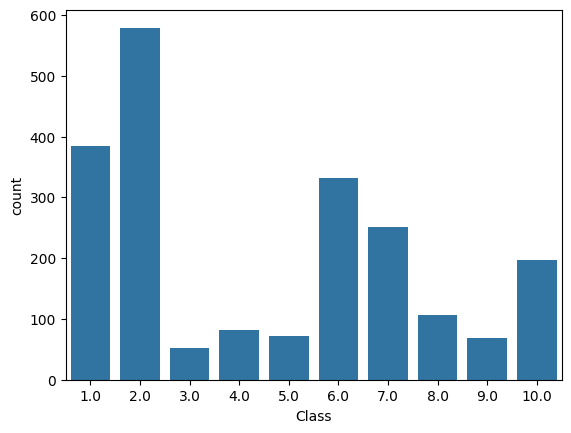

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.show()

In [72]:
df.dtypes

V1         int64
V2         int64
V3         int64
V4         int64
V5         int64
V6         int64
V7         int64
V8         int64
V9         int64
V10      float64
V11        int64
V12      float64
V13        int64
V14        int64
V15        int64
V16        int64
V17        int64
V18        int64
V19        int64
V20        int64
V21        int64
V22        int64
V23        int64
V24        int64
V25        int64
V26        int64
V27        int64
V28        int64
V29        int64
V30        int64
V31        int64
V32        int64
V33        int64
V34        int64
V35        int64
Class    float64
dtype: object

## EDA

In [74]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,2125.0,25.113412,15.239236,1.0,10.0,29.0,39.0,48.0
V2,2125.0,878.721412,894.200875,0.0,55.0,538.0,1522.0,3296.0
V3,2125.0,1703.454118,930.758081,287.0,1009.0,1241.0,2435.0,3599.0
V4,2125.0,133.308235,9.841089,106.0,126.0,133.0,140.0,160.0
V5,2125.0,133.308235,9.841089,106.0,126.0,133.0,140.0,160.0
V6,2125.0,2.723765,3.561198,0.0,0.0,1.0,4.0,26.0
V7,2125.0,7.244706,37.133715,0.0,0.0,0.0,2.0,564.0
V8,2125.0,3.661647,2.846656,0.0,1.0,3.0,5.0,23.0
V9,2125.0,46.971765,17.176007,12.0,32.0,49.0,61.0,87.0
V10,2125.0,1.333224,0.883217,0.2,0.7,1.2,1.7,7.0


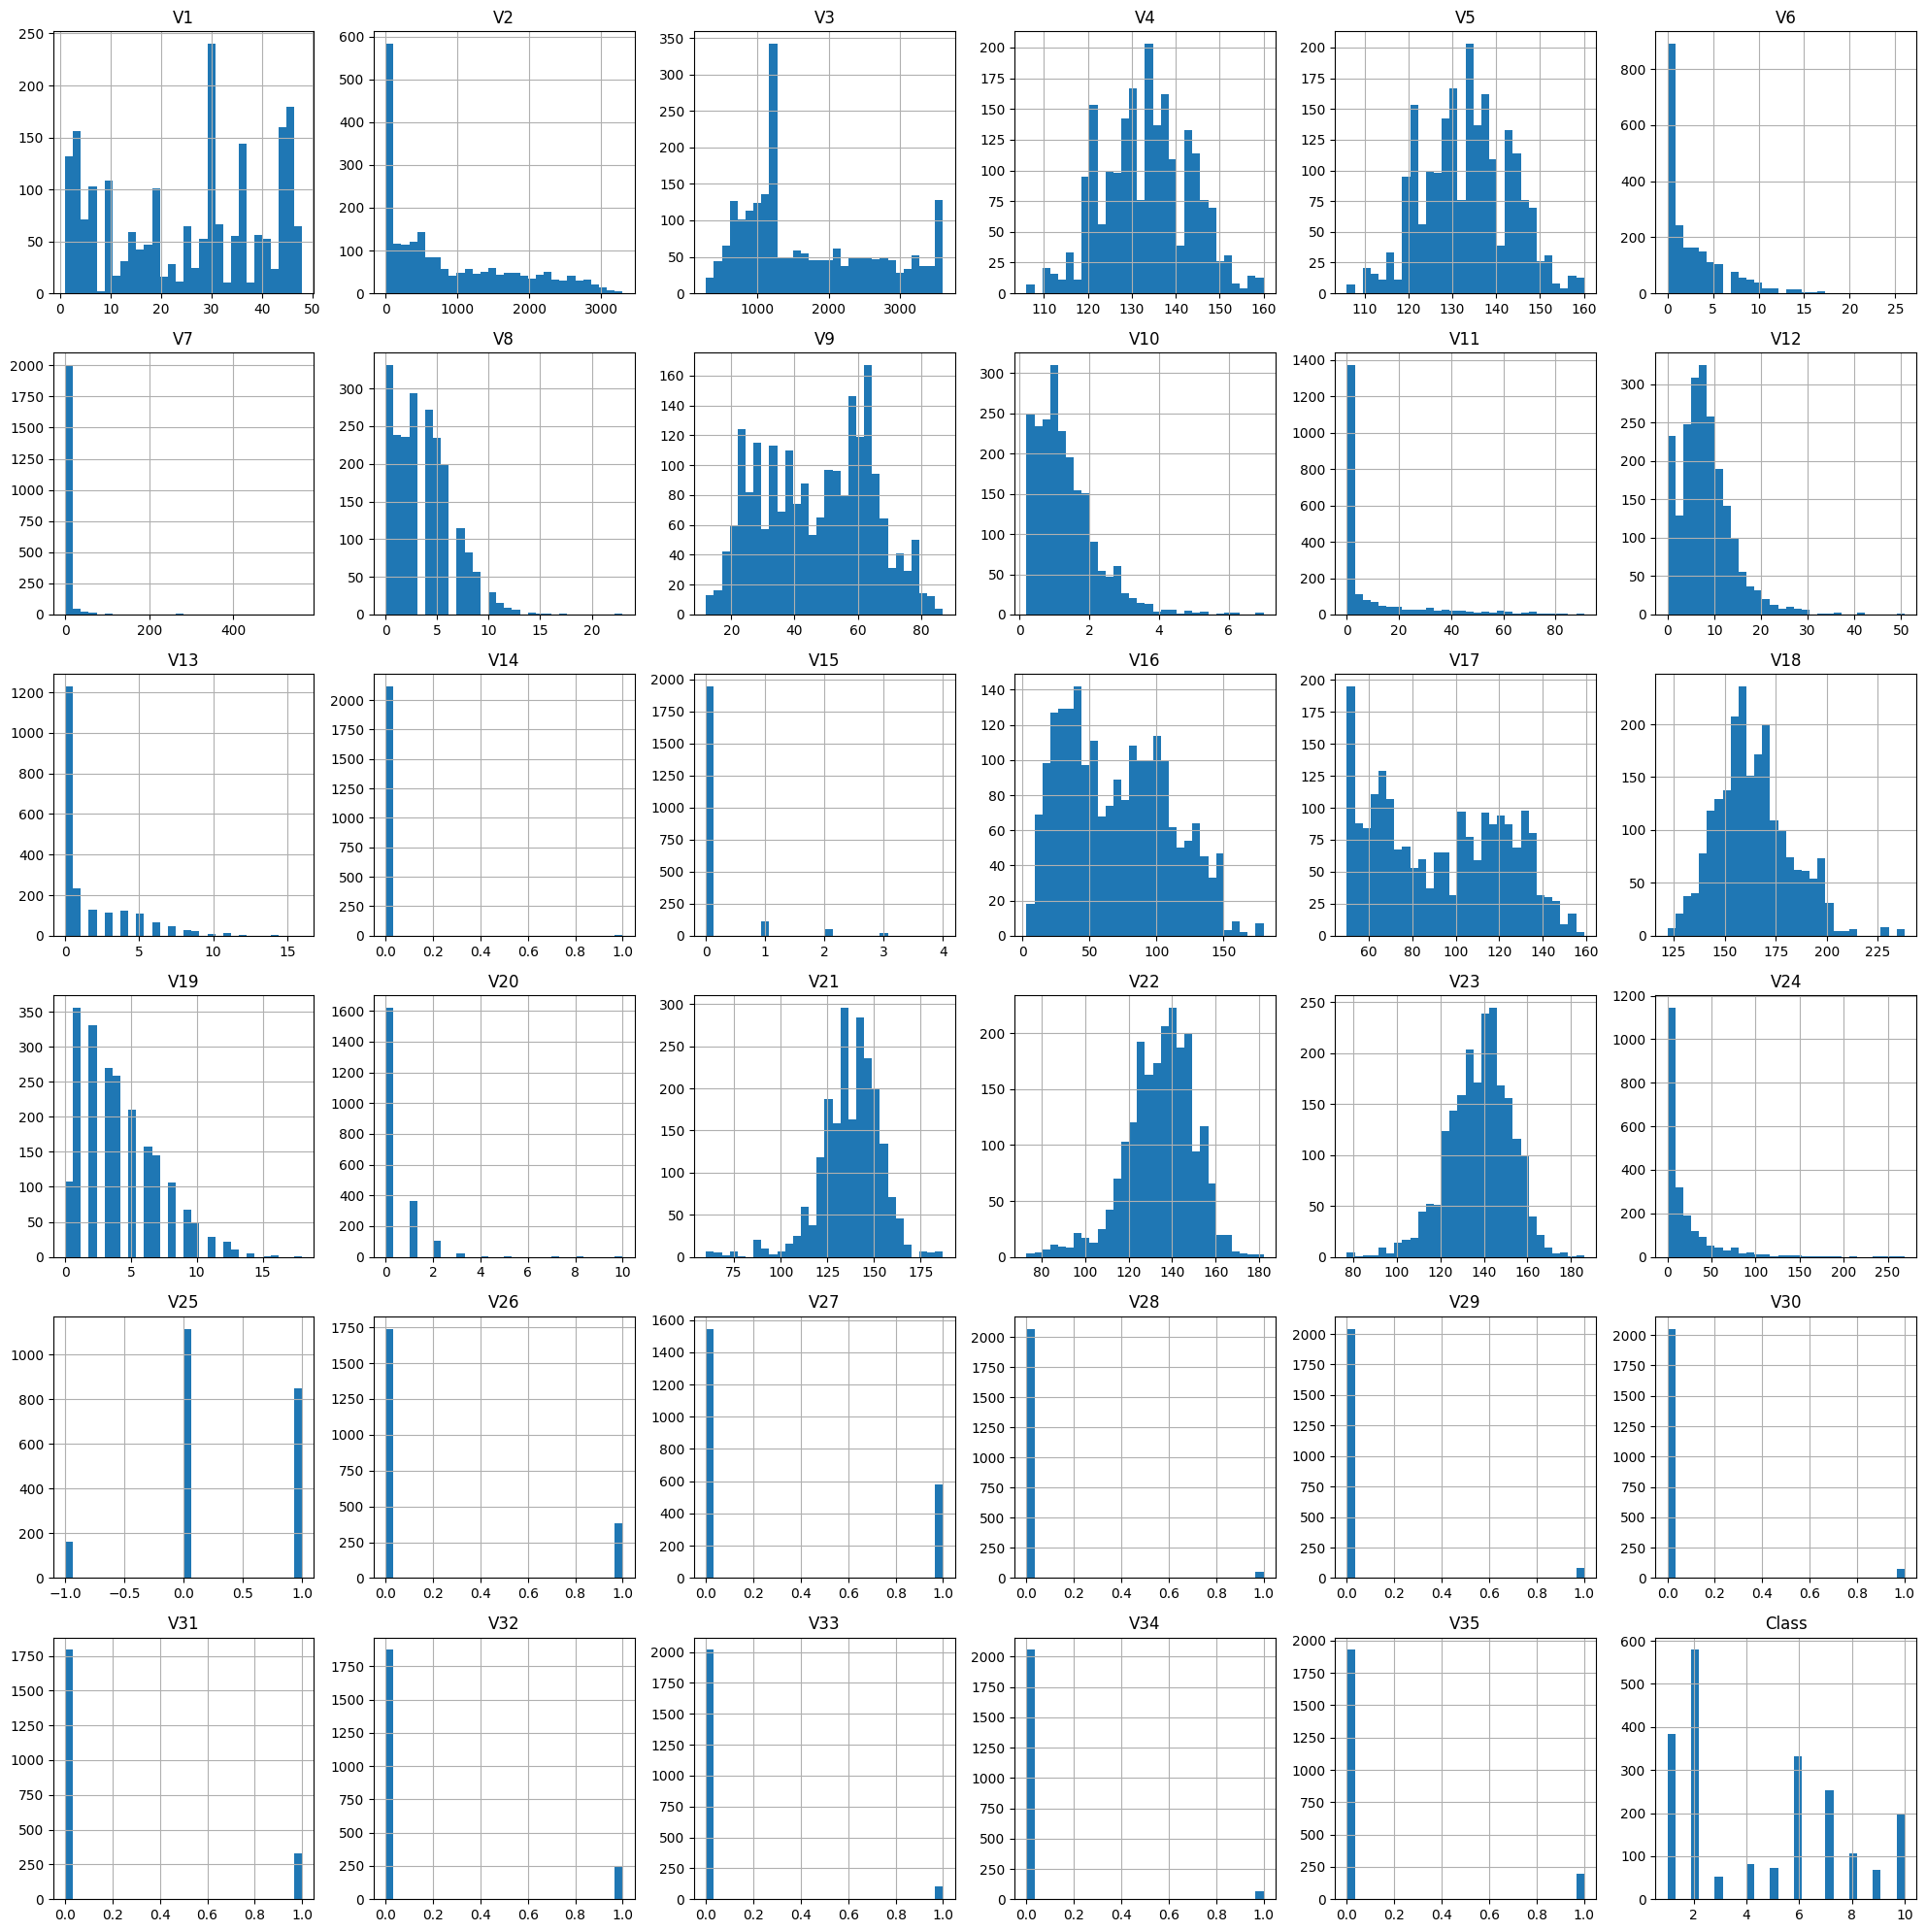

In [75]:
df.hist(figsize=(20,20), bins=30)
plt.tight_layout()
plt.show()

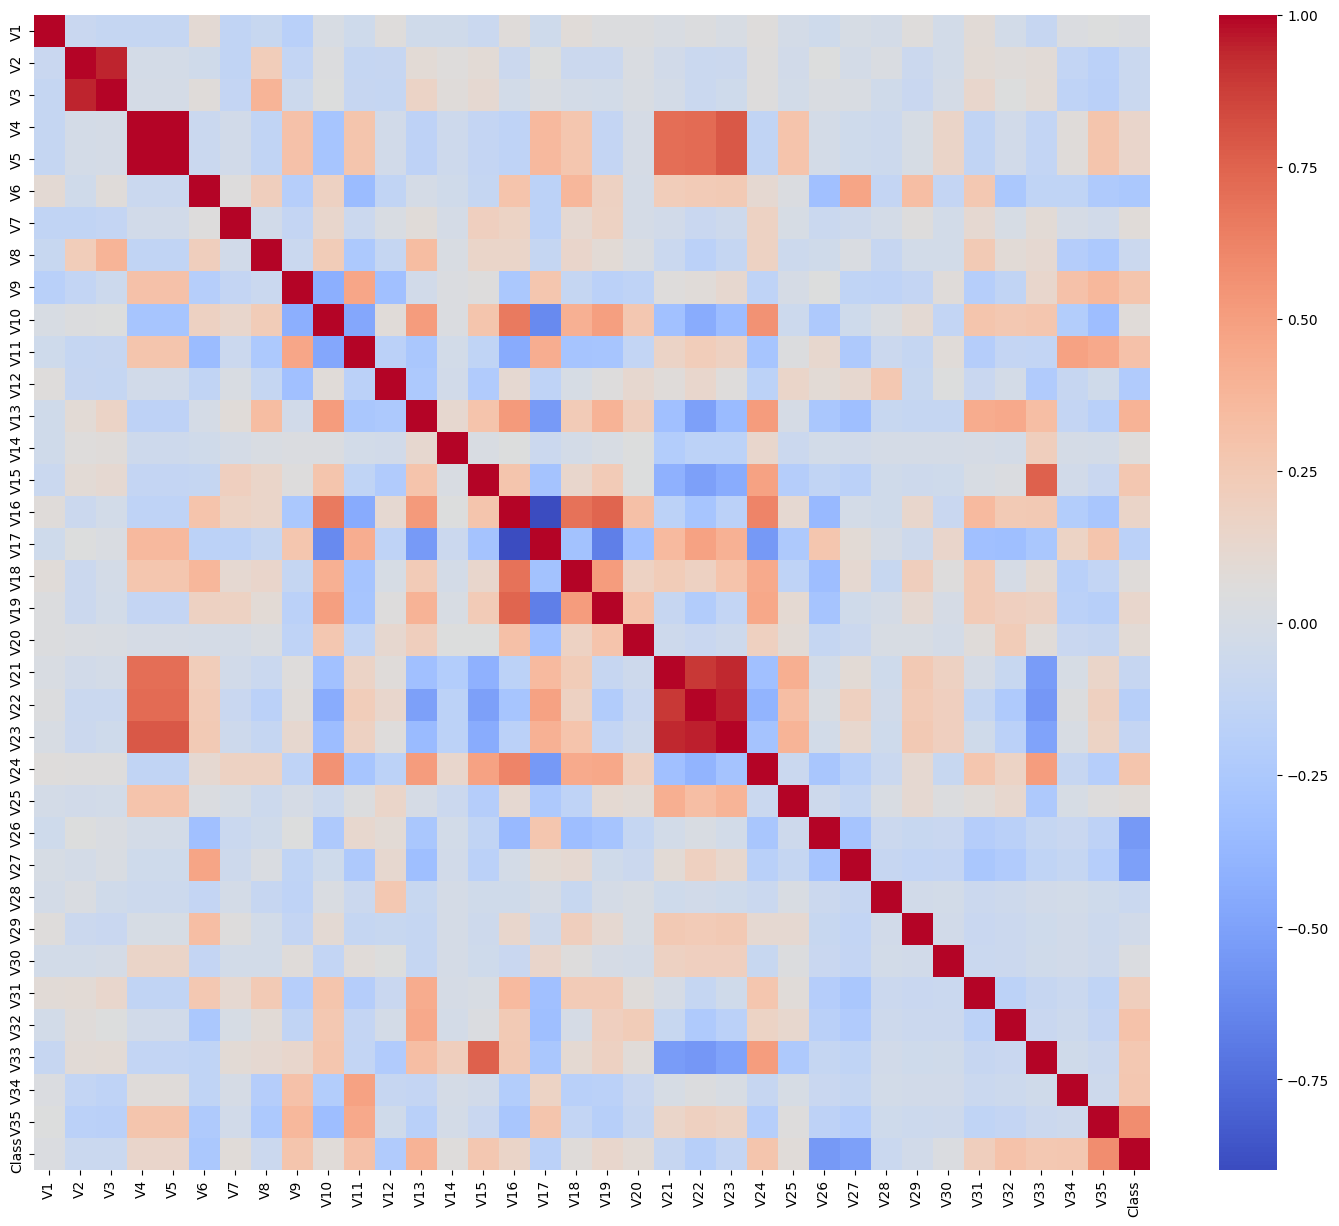

In [76]:
plt.figure(figsize=(18,15))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [77]:
print(df.shape)

df = df.drop_duplicates()

print(df.shape)

(2125, 36)
(2114, 36)


In [78]:
df.duplicated().sum()

np.int64(0)

## ```INDEPENDENT AND DEPENDENT FEATURES```

In [79]:
X = df.drop(columns=['Class'])
y = df['Class']

In [81]:
print(X.shape)
print(y.shape)

(2114, 35)
(2114,)


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y   ## stratify for imbalnced dataset
)

In [84]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1691, 35)
(423, 35)
Class
2.0     460
1.0     306
6.0     265
7.0     201
10.0    156
8.0      85
4.0      65
5.0      58
9.0      54
3.0      41
Name: count, dtype: int64
Class
2.0     115
1.0      77
6.0      67
7.0      50
10.0     39
8.0      22
4.0      16
5.0      14
9.0      13
3.0      10
Name: count, dtype: int64


## STandardScalling

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### ```Logistic Regression```

In [86]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [88]:
y_pred = lr.predict(X_test_scaled)

c:\Users\manis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [89]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9196217494089834
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99        77
         2.0       1.00      0.90      0.95       115
         3.0       0.38      0.90      0.53        10
         4.0       0.70      1.00      0.82        16
         5.0       1.00      0.71      0.83        14
         6.0       1.00      0.82      0.90        67
         7.0       0.98      0.92      0.95        50
         8.0       0.81      1.00      0.90        22
         9.0       0.72      1.00      0.84        13
        10.0       1.00      0.97      0.99        39

    accuracy                           0.92       423
   macro avg       0.86      0.92      0.87       423
weighted avg       0.95      0.92      0.93       423

[[ 76   0   0   0   0   0   1   0   0   0]
 [  0 104   6   4   0   0   0   0   1   0]
 [  0   0   9   0   0   0   0   0   1   0]
 [  0   0   0  16   0   0   0   0   0   0]
 [  1   0   0   0  10   0   0   0   3  

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'GaussianNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis()
}

# Models that require scaling
scaled_models = [
    'Logistic Regression',
    'KNN',
    'SVM',
    'LDA',
    'GaussianNB'
]

for name, model in models.items():

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f'{name:<22}: {acc:.4f}')

Logistic Regression   : 1.0000
KNN                   : 0.9976
SVM                   : 0.9976
Decision Tree         : 1.0000
Random Forest         : 1.0000
Extra Trees           : 1.0000
AdaBoost              : 0.8747
Gradient Boosting     : 1.0000
GaussianNB            : 0.9976
LDA                   : 1.0000


In [96]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print(scores)
print("Mean Accuracy:", scores.mean())

[1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


In [97]:
corr = df.corr(numeric_only=True)

print(corr['Class'].sort_values(ascending=False))

Class    1.000000
V35      0.579197
V13      0.397962
V32      0.302678
V11      0.298774
V24      0.286027
V9       0.281857
V15      0.270025
V34      0.268875
V33      0.266778
V31      0.213153
V16      0.156441
V4       0.141926
V5       0.141926
V19      0.139407
V20      0.090264
V10      0.080063
V25      0.078228
V7       0.078019
V18      0.065887
V14      0.061149
V1       0.030864
V30      0.030616
V29     -0.033482
V8      -0.073742
V28     -0.078383
V2      -0.080882
V3      -0.081211
V21     -0.100058
V23     -0.117882
V17     -0.166483
V22     -0.191440
V12     -0.226367
V6      -0.254473
V27     -0.506909
V26     -0.545686
Name: Class, dtype: float64


In [98]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

   Feature  Importance
26     V27    0.148226
25     V26    0.129797
30     V31    0.089348
5       V6    0.082827
12     V13    0.077740
31     V32    0.068135
34     V35    0.059268
23     V24    0.037513
28     V29    0.030352
21     V22    0.023940
